In [6]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier


In [7]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X_full, y_full = make_moons(n_samples=1000, noise=0.4) 
X_train, X_test_valid, y_train, y_test_valid = train_test_split(X_full, y_full, test_size=0.3, random_state=39)
X_test, X_valid, y_test, y_valid = train_test_split(X_test_valid, y_test_valid, test_size=0.5, random_state=39)



In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier

# --- AdaBoost ---
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    random_state=39
)

adaboost_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.5, 1.0],
    "estimator__max_depth": [1, 2]
}

adaboost_grid = GridSearchCV(adaboost, adaboost_params, cv=5, scoring="accuracy", n_jobs=-1)
adaboost_grid.fit(X_train, y_train)
model = adaboost_grid.best_estimator_


# --- Bagging ---
# bagging = BaggingClassifier(
#     estimator=DecisionTreeClassifier(),
#     random_state=39
# )

# bagging_params = {
#     "n_estimators": [50, 100, 200],
#     "max_samples": [50, 100, 200],
#     "estimator__max_depth": [None, 5, 10]
# }

# bagging_grid = GridSearchCV(bagging, bagging_params, cv=5, scoring="accuracy", n_jobs=-1)
# bagging_grid.fit(X_train, y_train)


# --- Decision Tree ---
# tree = DecisionTreeClassifier(random_state=39)

# tree_params = {
#     "max_depth": [2, 3, 5, None],
#     "max_leaf_nodes": [5, 10, 20, None],
#     "min_samples_split": [2, 5, 10]
# }

# tree_grid = GridSearchCV(tree, tree_params, cv=5, scoring="accuracy", n_jobs=-1)
# tree_grid.fit(X_train, y_train)


# --- Best results ---
print("AdaBoost best:", adaboost_grid.best_params_, adaboost_grid.best_score_)
# print("Bagging best:", bagging_grid.best_params_, bagging_grid.best_score_)
# print("Decision Tree best:", tree_grid.best_params_, tree_grid.best_score_)


AdaBoost best: {'estimator__max_depth': 2, 'learning_rate': 1.0, 'n_estimators': 50} 0.8685714285714287


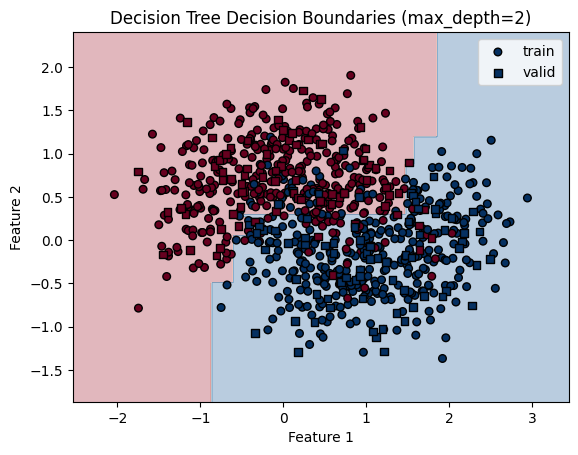

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# grid for plotting
x_min, x_max = X_full[:, 0].min() - 0.5, X_full[:, 0].max() + 0.5
y_min, y_max = X_full[:, 1].min() - 0.5, X_full[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)

# plot training points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k", cmap=plt.cm.RdBu, s=30, label="train")
plt.scatter(X_valid[:, 0], X_valid[:, 1], c=y_valid, edgecolor="k", cmap=plt.cm.RdBu, s=30, marker="s", label="valid")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Tree Decision Boundaries (max_depth=2)")
plt.legend()
plt.show()
